[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-foundations/torch_measure/blob/main/tutorials/network_psychometrics.ipynb)

# Network Psychometrics with torch_measure

**Network psychometrics** models the item response matrix as a network of conditional dependencies rather than as reflections of a single latent trait. Instead of asking *"what ability score explains this response pattern?"*, it asks *"which items activate each other after conditioning on all other items?"*.

torch_measure supports two canonical network models:

| Model | Response type | Key idea |
|-------|--------------|----------|
| **IsingModel** | Binary {0, 1} | Pairwise Markov Random Field; fit via Maximum Pseudo-Likelihood |
| **GaussianGraphicalModel** | Continuous | Sparse precision matrix; fit via GraphicalLasso |

Both models expose a common interface:
- `.fit(response_matrix)` — estimate the network
- `.adjacency` — (n_items, n_items) edge-weight matrix
- `.centrality(measure)` — node-level centrality scores

### References
- Epskamp, S., & Fried, E. I. (2018). A tutorial on regularized partial correlation networks. *Psychological Methods*, 23(4), 617.
- van Borkulo, C. D., et al. (2014). A new method for constructing networks from binary data. *Scientific Reports*, 4, 5918.
- Friedman, J., Hastie, T., & Tibshirani, R. (2008). Sparse inverse covariance estimation with the graphical lasso. *Biostatistics*, 9(3).

## 1. Setup

In [1]:
try:
    import google.colab
    !git clone https://github.com/aims-foundations/torch_measure.git
    !pip install -e torch_measure
except ImportError:
    pass  # Already installed locally

import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from torch_measure.models import IsingModel, GaussianGraphicalModel
from torch_measure.metrics import (
    strength_centrality,
    expected_influence,
    closeness_centrality,
    betweenness_centrality,
)

torch.manual_seed(42)
plt.rcParams["figure.dpi"] = 100
print("Setup complete")

Setup complete


### Visualisation helper

We will reuse a small helper that draws a network from an adjacency matrix. Blue edges are positive, red edges are negative.

In [2]:
import math

def plot_network(adjacency, labels=None, title="", threshold=0.0, ax=None):
    """Draw a circular network layout from an adjacency matrix.

    Parameters
    ----------
    adjacency : torch.Tensor  (n, n), zero diagonal
    labels    : list[str] | None
    title     : str
    threshold : float  — edges with |w| <= threshold are hidden
    ax        : matplotlib Axes
    """
    A = adjacency.cpu().numpy()
    n = A.shape[0]
    if labels is None:
        labels = [f"i{j}" for j in range(n)]

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    # Circular node positions
    angles = [2 * math.pi * k / n for k in range(n)]
    pos = {k: (math.cos(a), math.sin(a)) for k, a in enumerate(angles)}

    vmax = max(abs(A).max(), 1e-6)

    # Draw edges
    for i in range(n):
        for j in range(i + 1, n):
            w = A[i, j]
            if abs(w) <= threshold:
                continue
            color = "steelblue" if w > 0 else "tomato"
            lw = abs(w) / vmax * 4
            xi, yi = pos[i]
            xj, yj = pos[j]
            ax.plot([xi, xj], [yi, yj], color=color, lw=lw, alpha=0.7, zorder=1)

    # Draw nodes
    for k, (x, y) in pos.items():
        ax.scatter(x, y, s=300, c="white", edgecolors="black", zorder=2, linewidths=1.5)
        ax.text(x * 1.18, y * 1.18, labels[k], ha="center", va="center", fontsize=8)

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=10)

    # Legend
    from matplotlib.lines import Line2D
    legend = [
        Line2D([0], [0], color="steelblue", lw=2, label="positive edge"),
        Line2D([0], [0], color="tomato", lw=2, label="negative edge"),
    ]
    ax.legend(handles=legend, loc="lower right", fontsize=7)

---
## 2. Ising Model (Binary Data)

The **Ising model** is a pairwise Markov Random Field (MRF) for binary item responses. The joint probability is

$$P(\mathbf{x}) \propto \exp\!\bigl(\boldsymbol{\tau}^\top \mathbf{x} + \mathbf{x}^\top \Theta\, \mathbf{x}\bigr)$$

where $\boldsymbol{\tau} \in \mathbb{R}^n$ are **node thresholds** and $\Theta \in \mathbb{R}^{n \times n}$ is the symmetric **weight matrix** (zero diagonal).

The conditional probability of item $j$ given all other items is simply a logistic function:
$$P(X_j = 1 \mid X_{-j}) = \sigma\!\bigl(\tau_j + \textstyle\sum_{k \ne j} \Theta_{jk}\, X_k\bigr)$$

Because the partition function is intractable for large $n$, parameters are estimated via **Maximum Pseudo-Likelihood (MPLE)** — the sum of node-conditional log-likelihoods.

### 2a. Generating binary data with a known block structure

We create a 3-community Ising network: items 0–3 form cluster A, items 4–7 form cluster B, items 8–11 form cluster C.  Within a cluster edges are strong and positive; between clusters they are weak.

In [3]:
torch.manual_seed(0)

n_items = 12
n_subjects = 500

# Build a true weight matrix with block structure
true_W = torch.zeros(n_items, n_items)
clusters = [list(range(0, 4)), list(range(4, 8)), list(range(8, 12))]
for cluster in clusters:
    for i in cluster:
        for j in cluster:
            if i != j:
                true_W[i, j] = 0.8   # strong within-cluster

true_tau = torch.zeros(n_items)   # neutral thresholds

# Sample from the Ising model via block Gibbs sampling
def gibbs_sample_ising(W, tau, n_subjects, n_burn=200, n_thin=5):
    n = W.shape[0]
    X = torch.bernoulli(torch.full((n,), 0.5))  # random init
    samples = []
    total_steps = n_burn + n_subjects * n_thin
    for step in range(total_steps):
        for j in range(n):
            logit_j = tau[j] + (W[:, j] * X).sum() - W[j, j] * X[j]
            X[j] = torch.bernoulli(torch.sigmoid(logit_j))
        if step >= n_burn and (step - n_burn) % n_thin == 0:
            samples.append(X.clone())
    return torch.stack(samples)

binary_responses = gibbs_sample_ising(true_W, true_tau, n_subjects)
print(f"Response matrix shape: {binary_responses.shape}")
print(f"Item means: {binary_responses.mean(dim=0).round(decimals=2)}")

Response matrix shape: torch.Size([500, 12])
Item means: tensor([0.8800, 0.8900, 0.8500, 0.8700, 0.8700, 0.8800, 0.8700, 0.8800, 0.8700,
        0.8900, 0.9000, 0.8900])


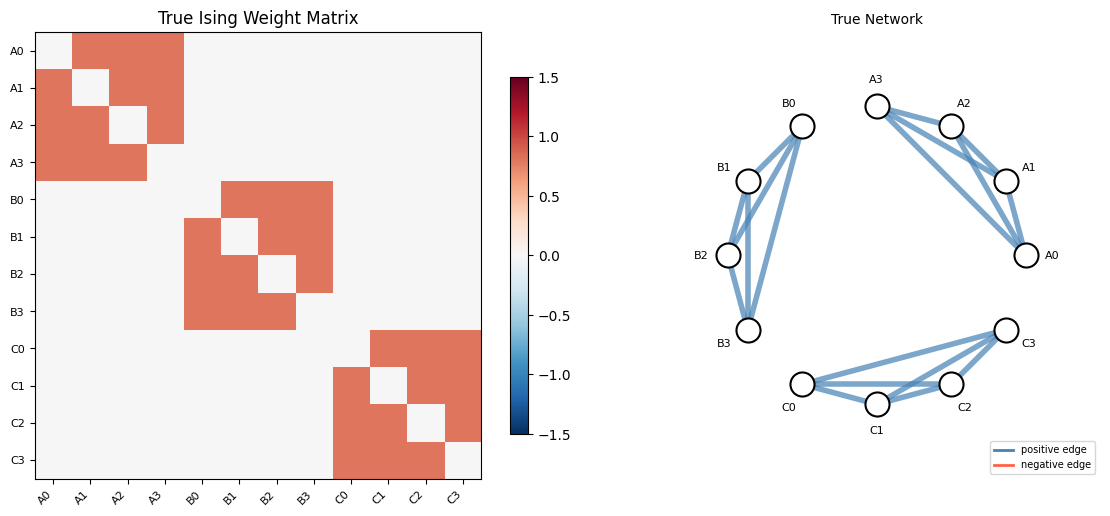

In [4]:
# Visualise the true network structure
item_labels = [f"A{i}" if i < 4 else (f"B{i-4}" if i < 8 else f"C{i-8}") for i in range(n_items)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Adjacency heatmap
im = axes[0].imshow(true_W.numpy(), cmap="RdBu_r", vmin=-1.5, vmax=1.5)
axes[0].set_xticks(range(n_items))
axes[0].set_yticks(range(n_items))
axes[0].set_xticklabels(item_labels, rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels(item_labels, fontsize=8)
axes[0].set_title("True Ising Weight Matrix")
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Network diagram
plot_network(true_W, labels=item_labels, title="True Network", threshold=0.1, ax=axes[1])

plt.tight_layout()
plt.show()

### 2b. Fitting the Ising model

In [5]:
ising = IsingModel(n_items=n_items)
history = ising.fit(binary_responses, max_epochs=200, lr=0.05, verbose=True)

print(f"\nInitial loss: {history['losses'][0]:.4f}")
print(f"Final loss:   {history['losses'][-1]:.4f}")

Ising MPLE:   0%|          | 0/200 [00:00<?, ?it/s]

Ising MPLE:   0%|          | 0/200 [00:01<?, ?it/s, loss=0.693147]

Ising MPLE:   0%|          | 1/200 [00:01<06:34,  1.98s/it, loss=0.693147]

Ising MPLE:   0%|          | 1/200 [00:01<06:34,  1.98s/it, loss=0.524870]

Ising MPLE:   0%|          | 1/200 [00:01<06:34,  1.98s/it, loss=0.425142]

...

Ising MPLE:  92%|█████████▎| 185/200 [00:02<00:00, 159.59it/s, loss=0.339690]

Ising MPLE:  92%|█████████▎| 185/200 [00:02<00:00, 159.59it/s, loss=0.339682]

Ising MPLE:  92%|█████████▎| 185/200 [00:02<00:00, 159.59it/s, loss=0.339674]

Ising MPLE: 100%|██████████| 200/200 [00:02<00:00, 82.49it/s, loss=0.339674] 


Initial loss: 0.6931
Final loss:   0.3397


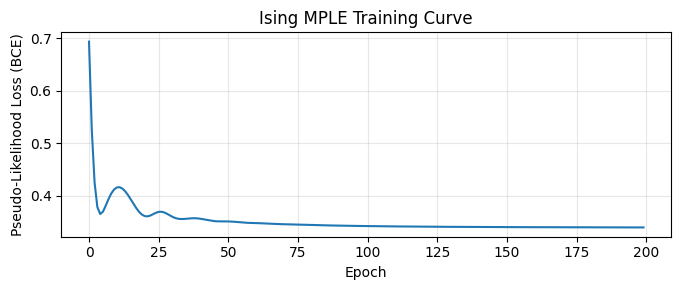

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["losses"])
ax.set_xlabel("Epoch")
ax.set_ylabel("Pseudo-Likelihood Loss (BCE)")
ax.set_title("Ising MPLE Training Curve")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2c. Inspecting the estimated network

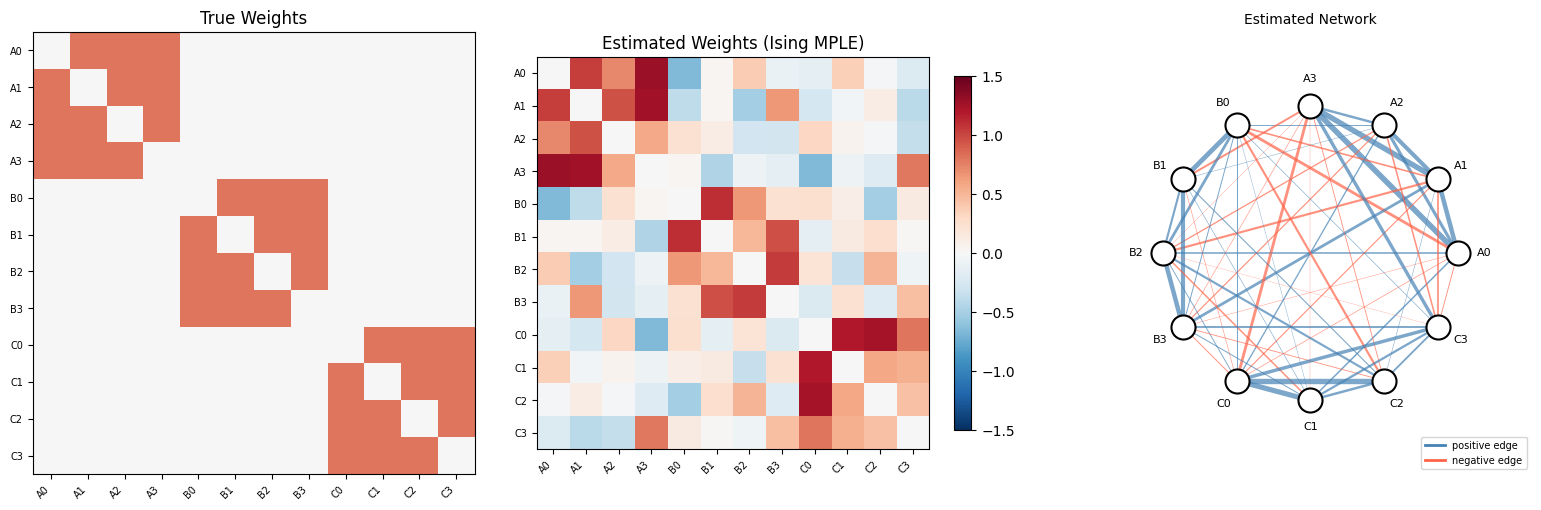

Correlation between true and estimated weights (off-diagonal): r = 0.774


In [7]:
est_W = ising.adjacency   # (n_items, n_items), symmetric, zero diagonal

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# True weights heatmap
axes[0].imshow(true_W.numpy(), cmap="RdBu_r", vmin=-1.5, vmax=1.5)
axes[0].set_title("True Weights")
axes[0].set_xticks(range(n_items)); axes[0].set_xticklabels(item_labels, rotation=45, ha="right", fontsize=7)
axes[0].set_yticks(range(n_items)); axes[0].set_yticklabels(item_labels, fontsize=7)

# Estimated weights heatmap
im = axes[1].imshow(est_W.numpy(), cmap="RdBu_r", vmin=-1.5, vmax=1.5)
axes[1].set_title("Estimated Weights (Ising MPLE)")
axes[1].set_xticks(range(n_items)); axes[1].set_xticklabels(item_labels, rotation=45, ha="right", fontsize=7)
axes[1].set_yticks(range(n_items)); axes[1].set_yticklabels(item_labels, fontsize=7)
plt.colorbar(im, ax=axes[1], shrink=0.8)

# Network diagram
plot_network(est_W, labels=item_labels, title="Estimated Network", threshold=0.05, ax=axes[2])

plt.tight_layout()
plt.show()

# Correlation between true and estimated off-diagonal weights
mask_off = ~torch.eye(n_items, dtype=torch.bool)
r = torch.corrcoef(torch.stack([true_W[mask_off], est_W[mask_off]]))[0, 1]
print(f"Correlation between true and estimated weights (off-diagonal): r = {r:.3f}")

### 2d. Node thresholds and conditional probabilities

The Ising model also learns a **threshold** τⱼ per item — its marginal log-odds when all neighbours are inactive.

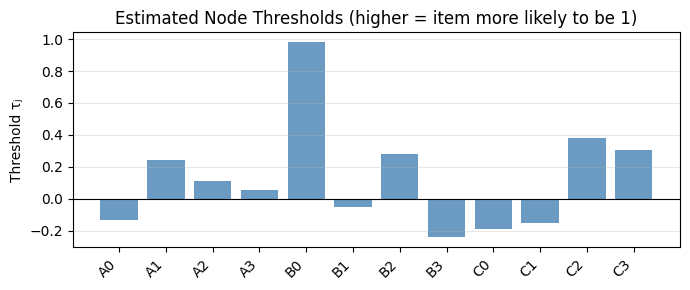

Conditional P(X_j=1 | X_{-j}) — mean per item:
tensor([0.8790, 0.8890, 0.8520, 0.8680, 0.8680, 0.8850, 0.8710, 0.8780, 0.8730,
        0.8910, 0.8970, 0.8870], grad_fn=<RoundBackward1>)


In [8]:
tau = ising.thresholds.detach()

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(n_items), tau.numpy(), color="steelblue", alpha=0.8)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xticks(range(n_items))
ax.set_xticklabels(item_labels, rotation=45, ha="right")
ax.set_ylabel("Threshold τⱼ")
ax.set_title("Estimated Node Thresholds (higher = item more likely to be 1)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Conditional probabilities on the training data
cond_probs = ising.conditional_probs(binary_responses)  # (n_subjects, n_items)
print(f"Conditional P(X_j=1 | X_{{-j}}) — mean per item:")
print(cond_probs.mean(dim=0).round(decimals=3))

### 2e. Node centrality

Centrality metrics summarise how *influential* or *connected* each node is in the network.

| Measure | Formula | Interpretation |
|---------|---------|---------------|
| **Strength** | Σ\|wᵢⱼ\| | Total absolute connectivity |
| **Expected influence** | Σwᵢⱼ | Signed connectivity (sensitive to edge polarity) |
| **Closeness** | (n−1) / Σdist(i,j) | How quickly a node reaches all others |
| **Betweenness** | fraction of shortest paths through node | Bridges between communities |

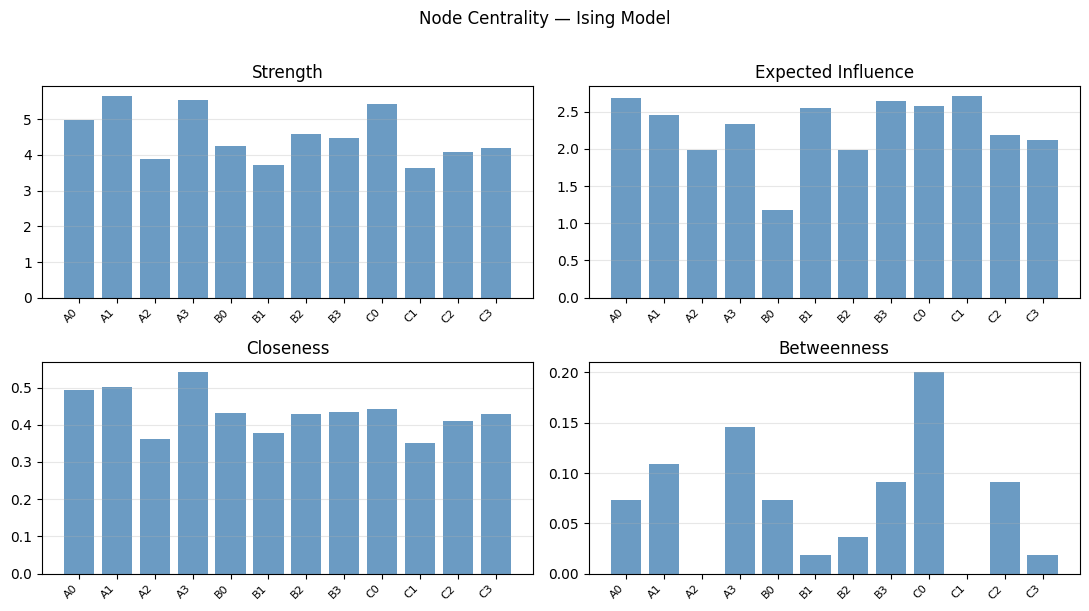

Most central item by strength: A1 (strength = 5.643)


In [9]:
W = ising.adjacency

s   = strength_centrality(W)
ei  = expected_influence(W)
cl  = closeness_centrality(W)
bt  = betweenness_centrality(W)

# Also available via the model convenience method:
# s = ising.centrality("strength")

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
x = range(n_items)

for ax, values, label in zip(
    axes.flat,
    [s, ei, cl, bt],
    ["Strength", "Expected Influence", "Closeness", "Betweenness"],
):
    colors = ["steelblue" if v >= 0 else "tomato" for v in values.numpy()]
    ax.bar(x, values.numpy(), color=colors, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(item_labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(label)
    ax.axhline(0, color="k", linewidth=0.5)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Node Centrality — Ising Model", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Most central item by strength
top_item = s.argmax().item()
print(f"Most central item by strength: {item_labels[top_item]} (strength = {s[top_item]:.3f})")

### 2f. Handling missing data

Pass `NaN` for missing entries. The MPLE loss is computed only on observed (subject, item) pairs.

In [10]:
torch.manual_seed(1)

# Introduce 20% missing at random
responses_missing = binary_responses.clone().float()
responses_missing[torch.rand_like(responses_missing) < 0.20] = float("nan")
observed_frac = (~responses_missing.isnan()).float().mean().item()

print(f"Observed fraction: {observed_frac:.1%}")

ising_missing = IsingModel(n_items=n_items)
ising_missing.fit(responses_missing, max_epochs=200, lr=0.05, verbose=False)

r_missing = torch.corrcoef(torch.stack([est_W[mask_off], ising_missing.adjacency[mask_off]]))[0, 1]
print(f"Correlation with full-data estimates: r = {r_missing:.3f}")
print("Network structure is largely preserved despite 20% missing data.")

Observed fraction: 79.6%


Correlation with full-data estimates: r = 0.765
Network structure is largely preserved despite 20% missing data.


---
## 3. Gaussian Graphical Model (Continuous Data)

The **GGM** models continuous responses as multivariate Gaussian:

$$\mathbf{X} \sim \mathcal{N}(\boldsymbol{\mu},\, \Sigma), \quad K = \Sigma^{-1} \text{ (precision matrix)}$$

An off-diagonal element $K_{ij} \ne 0$ implies items $i$ and $j$ are conditionally dependent given all other items. The **partial correlation** is

$$\text{pcor}_{ij} = -K_{ij} \big/ \sqrt{K_{ii}\, K_{jj}}$$

and forms the edge weight in the network.

Fitting minimises the **GraphicalLasso** objective:

$$\mathcal{L}(K) = -\log\det K + \operatorname{tr}(SK) + \lambda \sum_{i \ne j} |K_{ij}|$$

The $\lambda$ penalty controls network **sparsity** — larger $\lambda$ zeros out weak edges.

### 3a. Generating continuous data with a known precision structure

In [11]:
torch.manual_seed(0)

n_items_ggm = 10
n_subjects_ggm = 300

# Build a sparse true precision matrix: chain graph (AR(1)-like)
# Items are connected sequentially: 0-1, 1-2, ..., 8-9
K_true = torch.eye(n_items_ggm)
for i in range(n_items_ggm - 1):
    K_true[i, i + 1] = 0.6
    K_true[i + 1, i] = 0.6
# Make strictly diagonally dominant → positive definite
K_true += 0.5 * torch.eye(n_items_ggm)

# Sample from N(0, K_true^{-1})
Sigma_true = torch.linalg.inv(K_true)
L_true = torch.linalg.cholesky(Sigma_true)
continuous_responses = (torch.randn(n_subjects_ggm, n_items_ggm) @ L_true.T)

print(f"Response matrix shape: {continuous_responses.shape}")
print(f"Column means (should be ≈0): {continuous_responses.mean(dim=0).round(decimals=3)}")

# True partial correlations
D_inv_sqrt = 1.0 / K_true.diagonal().sqrt()
pcor_true = -K_true * D_inv_sqrt.unsqueeze(0) * D_inv_sqrt.unsqueeze(1)
pcor_true.fill_diagonal_(0.0)

print(f"\nTrue non-zero edges (|pcor| > 0.1): {(pcor_true.abs() > 0.1).sum().item() // 2}")

Response matrix shape: torch.Size([300, 10])
Column means (should be ≈0): tensor([-0.0390, -0.0590,  0.0450, -0.0270,  0.1090,  0.0360, -0.1170,  0.1910,
        -0.1260, -0.0080])

True non-zero edges (|pcor| > 0.1): 9


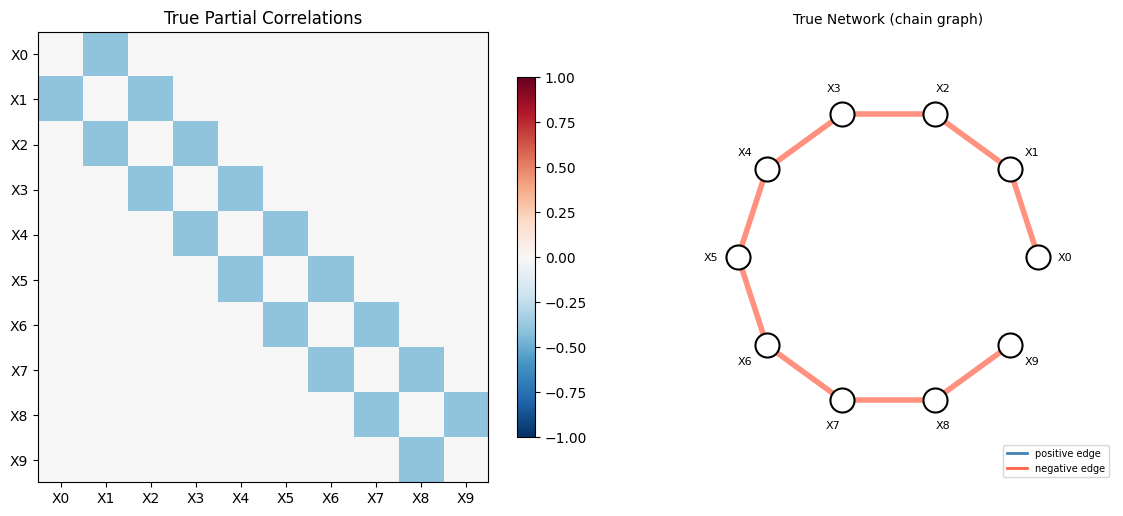

In [12]:
item_labels_ggm = [f"X{i}" for i in range(n_items_ggm)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(pcor_true.numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(n_items_ggm))
axes[0].set_yticks(range(n_items_ggm))
axes[0].set_xticklabels(item_labels_ggm)
axes[0].set_yticklabels(item_labels_ggm)
axes[0].set_title("True Partial Correlations")
plt.colorbar(im, ax=axes[0], shrink=0.8)

plot_network(pcor_true, labels=item_labels_ggm, title="True Network (chain graph)", threshold=0.05, ax=axes[1])

plt.tight_layout()
plt.show()

### 3b. Fitting the GGM

In [13]:
ggm = GaussianGraphicalModel(n_items=n_items_ggm, lam=0.05)
history_ggm = ggm.fit(continuous_responses, max_epochs=200, lr=0.02, verbose=True)

print(f"\nInitial loss: {history_ggm['losses'][0]:.3f}")
print(f"Final loss:   {history_ggm['losses'][-1]:.3f}")

GGM fitting:   0%|          | 0/200 [00:00<?, ?it/s]

GGM fitting:   0%|          | 0/200 [00:00<?, ?it/s, loss=12.4937]

GGM fitting:   0%|          | 0/200 [00:00<?, ?it/s, loss=11.9924]

GGM fitting:   0%|          | 0/200 [00:00<?, ?it/s, loss=11.5291]

GGM fitting:   0%|          | 0/200 [00:00<?, ?it/s, loss=11.1193]

...

GGM fitting:  75%|███████▌  | 150/200 [00:00<00:00, 721.96it/s, loss=8.2890]

GGM fitting:  75%|███████▌  | 150/200 [00:00<00:00, 721.96it/s, loss=8.2889]

GGM fitting:  75%|███████▌  | 150/200 [00:00<00:00, 721.96it/s, loss=8.2883]

GGM fitting: 100%|██████████| 200/200 [00:00<00:00, 722.88it/s, loss=8.2883]


Initial loss: 12.494
Final loss:   8.288


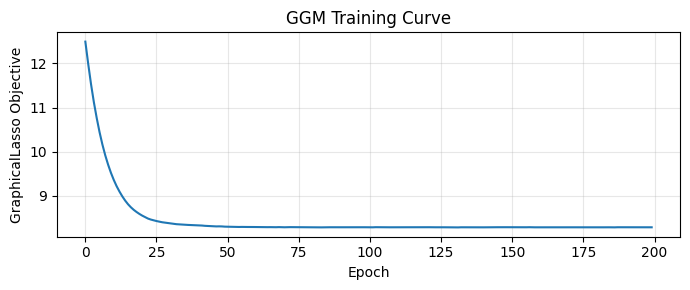

In [14]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history_ggm["losses"])
ax.set_xlabel("Epoch")
ax.set_ylabel("GraphicalLasso Objective")
ax.set_title("GGM Training Curve")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3c. Inspecting the estimated precision and partial correlations

Precision matrix eigenvalues — min: 0.3444, max: 2.3910
Positive definite: True


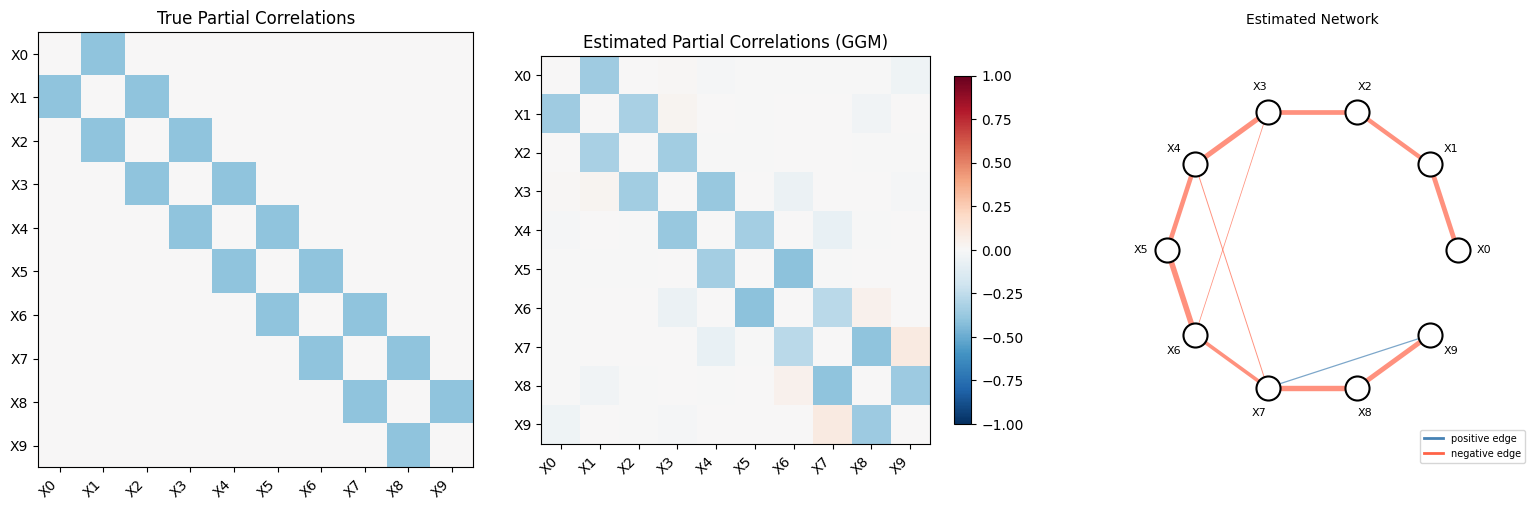


Correlation between true and estimated partial correlations: r = 0.980


In [15]:
K_est   = ggm.precision             # (n_items, n_items)
pcor_est = ggm.partial_correlations  # (n_items, n_items), diagonal = 1
W_est   = ggm.adjacency              # partial_correlations with zero diagonal

# Verify positive definiteness
eigs = torch.linalg.eigvalsh(K_est)
print(f"Precision matrix eigenvalues — min: {eigs.min():.4f}, max: {eigs.max():.4f}")
print(f"Positive definite: {(eigs > 0).all().item()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# True vs estimated partial correlations
axes[0].imshow(pcor_true.numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title("True Partial Correlations")
axes[0].set_xticks(range(n_items_ggm)); axes[0].set_xticklabels(item_labels_ggm, rotation=45, ha="right")
axes[0].set_yticks(range(n_items_ggm)); axes[0].set_yticklabels(item_labels_ggm)

im = axes[1].imshow(W_est.numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title("Estimated Partial Correlations (GGM)")
axes[1].set_xticks(range(n_items_ggm)); axes[1].set_xticklabels(item_labels_ggm, rotation=45, ha="right")
axes[1].set_yticks(range(n_items_ggm)); axes[1].set_yticklabels(item_labels_ggm)
plt.colorbar(im, ax=axes[1], shrink=0.8)

plot_network(W_est, labels=item_labels_ggm, title="Estimated Network", threshold=0.05, ax=axes[2])

plt.tight_layout()
plt.show()

# Recovery correlation (off-diagonal)
mask_off_ggm = ~torch.eye(n_items_ggm, dtype=torch.bool)
r_ggm = torch.corrcoef(torch.stack([pcor_true[mask_off_ggm], W_est[mask_off_ggm]]))[0, 1]
print(f"\nCorrelation between true and estimated partial correlations: r = {r_ggm:.3f}")

### 3d. Effect of the regularisation parameter λ

Larger $\lambda$ penalises off-diagonal precision entries more strongly, producing a sparser network. This is analogous to `EBICglasso` tuning in the R `qgraph` package.

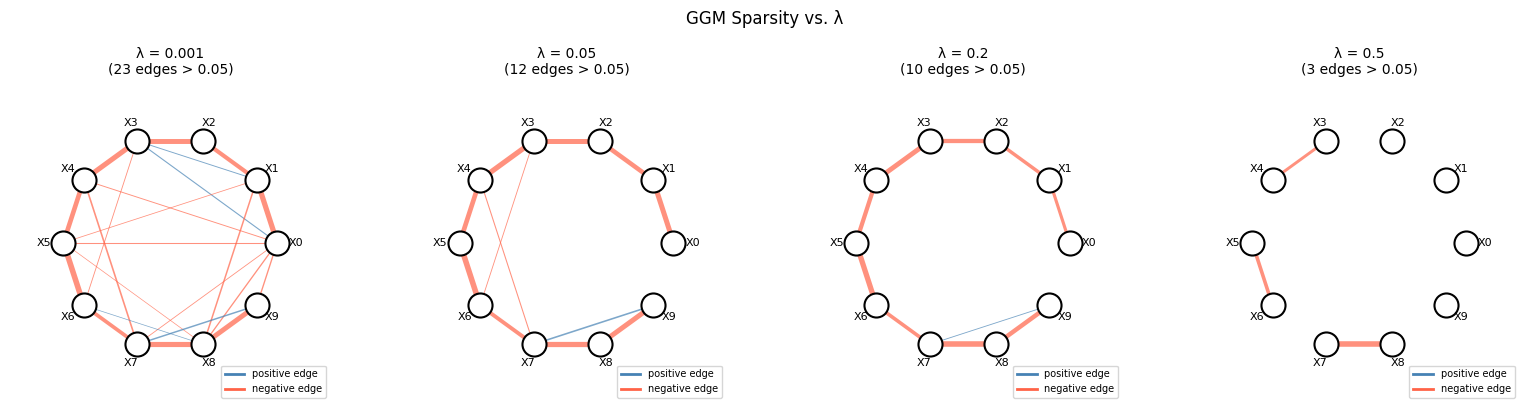

Larger λ → sparser network. Choose λ via cross-validation or EBIC.


In [16]:
lam_values = [0.001, 0.05, 0.2, 0.5]

fig, axes = plt.subplots(1, len(lam_values), figsize=(16, 4))

for ax, lam in zip(axes, lam_values):
    m = GaussianGraphicalModel(n_items=n_items_ggm, lam=lam)
    m.fit(continuous_responses, max_epochs=150, verbose=False)
    W = m.adjacency
    n_edges = (W.abs() > 0.05).sum().item() // 2
    plot_network(W, labels=item_labels_ggm, title=f"λ = {lam}\n({n_edges} edges > 0.05)",
                 threshold=0.05, ax=ax)

plt.suptitle("GGM Sparsity vs. λ", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("Larger λ → sparser network. Choose λ via cross-validation or EBIC.")

### 3e. Node centrality for the GGM

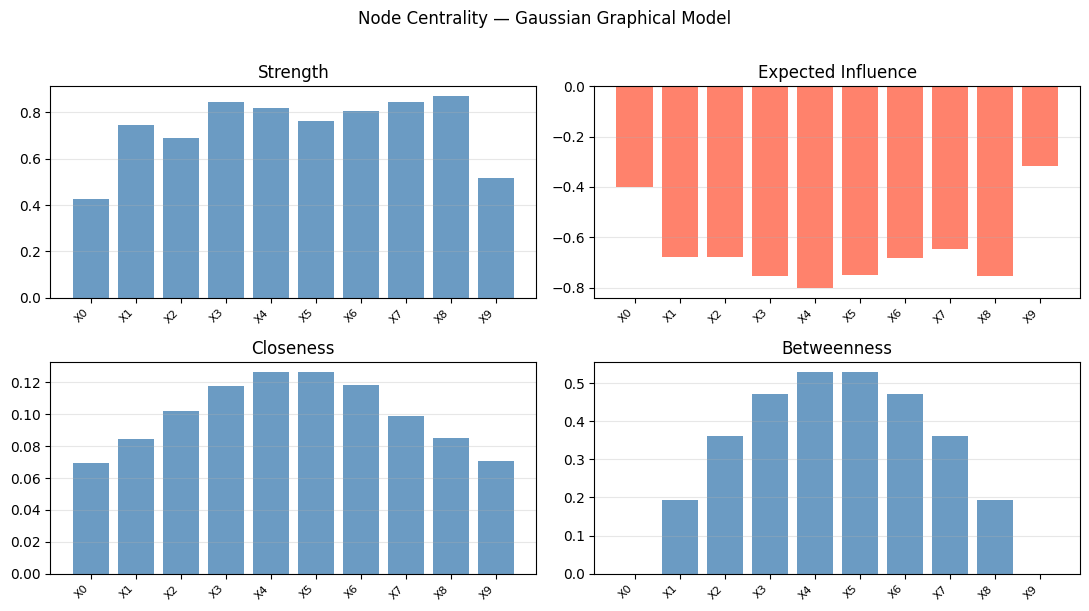

Endpoint betweenness  (X0): 0.000, (X9): 0.000
Interior betweenness  mean: 0.389
Interior nodes should have higher betweenness in a chain graph.


In [17]:
W_ggm = ggm.adjacency

s_ggm  = ggm.centrality("strength")
ei_ggm = ggm.centrality("expected_influence")
cl_ggm = ggm.centrality("closeness")
bt_ggm = ggm.centrality("betweenness")

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
x = range(n_items_ggm)

for ax, values, label in zip(
    axes.flat,
    [s_ggm, ei_ggm, cl_ggm, bt_ggm],
    ["Strength", "Expected Influence", "Closeness", "Betweenness"],
):
    colors = ["steelblue" if v >= 0 else "tomato" for v in values.numpy()]
    ax.bar(x, values.numpy(), color=colors, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(item_labels_ggm, rotation=45, ha="right", fontsize=8)
    ax.set_title(label)
    ax.axhline(0, color="k", linewidth=0.5)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Node Centrality — Gaussian Graphical Model", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Interior nodes in the chain graph (X1..X8) should have higher betweenness
# than endpoints (X0, X9)
print(f"Endpoint betweenness  (X0): {bt_ggm[0]:.3f}, (X9): {bt_ggm[9]:.3f}")
print(f"Interior betweenness  mean: {bt_ggm[1:-1].mean():.3f}")
print("Interior nodes should have higher betweenness in a chain graph.")

---
## 4. IRT vs. Network: Complementary Perspectives

IRT and network models answer different questions about the same data.

| | IRT (Rasch) | Network (Ising / GGM) |
|-|------------|----------------------|
| **Estimates** | Per-subject ability, per-item difficulty | Item-item edge weights |
| **Assumption** | Local independence given θ | Markov property over items |
| **Unit of analysis** | Subject | Item |
| **Fit criterion** | Bernoulli / Beta NLL | MPLE (Ising) / GraphicalLasso (GGM) |
| **Key output** | Ability scores, ICC curves | Adjacency matrix, centrality |
| **Good for** | Scoring, CAT, DIF | Item clustering, bridge detection |

Below we fit a Rasch model and an Ising model to the same binary data and show that the two perspectives are complementary: the Ising network reveals **item clusters** that the IRT model treats as residual noise.

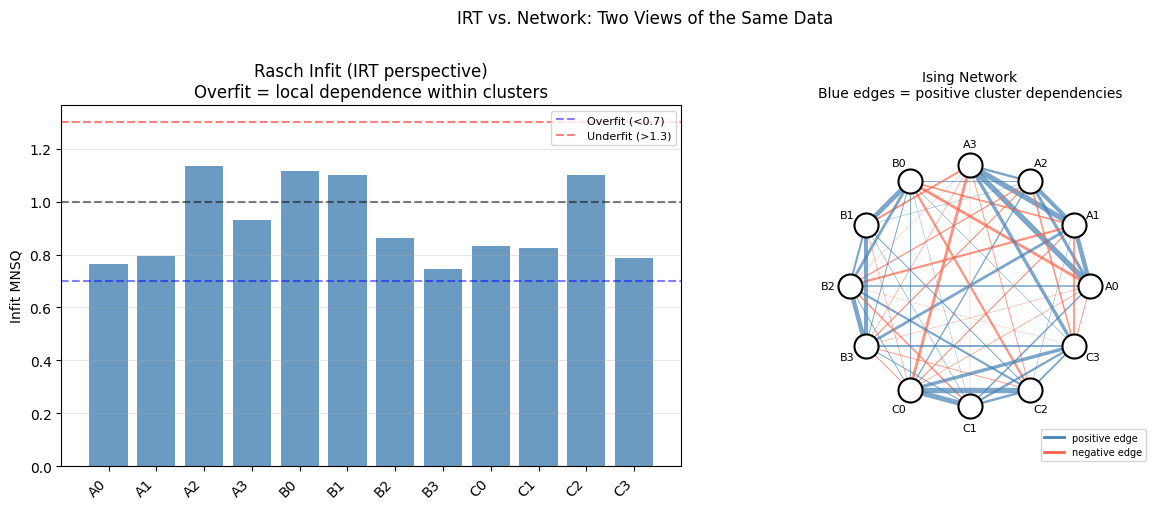

Items with infit < 0.7 (local dependence flag): 0 / 12
These items belong to tight clusters, visible as strong edges in the Ising network.


In [18]:
from torch_measure.models import Rasch, predict_dense

# Fit IRT on the binary data generated from the block Ising model
rasch_comp = Rasch(n_subjects=n_subjects, n_items=n_items)
rasch_comp.fit(binary_responses, max_epochs=150, verbose=False)

# IRT fit statistics — infit values should be around 1.0 for well-fitting items
from torch_measure.metrics import infit_statistics
probs = predict_dense(rasch_comp).detach()
infit = infit_statistics(probs, binary_responses)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Rasch infit: items within the same cluster may show overfit (infit < 0.7)
# because the network structure creates local dependence violating IRT assumptions
axes[0].bar(range(n_items), infit.numpy(), color="steelblue", alpha=0.8)
axes[0].axhline(1.0, color="k", linestyle="--", alpha=0.5)
axes[0].axhline(0.7, color="b", linestyle="--", alpha=0.5, label="Overfit (<0.7)")
axes[0].axhline(1.3, color="r", linestyle="--", alpha=0.5, label="Underfit (>1.3)")
axes[0].set_xticks(range(n_items))
axes[0].set_xticklabels(item_labels, rotation=45, ha="right")
axes[0].set_ylabel("Infit MNSQ")
axes[0].set_title("Rasch Infit (IRT perspective)\nOverfit = local dependence within clusters")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

# Network: the Ising adjacency directly encodes the cluster structure
plot_network(ising.adjacency, labels=item_labels,
             title="Ising Network\nBlue edges = positive cluster dependencies",
             threshold=0.05, ax=axes[1])

plt.suptitle("IRT vs. Network: Two Views of the Same Data", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

n_overfit = (infit < 0.7).sum().item()
print(f"Items with infit < 0.7 (local dependence flag): {n_overfit} / {n_items}")
print("These items belong to tight clusters, visible as strong edges in the Ising network.")

---
## 5.5. Part 2: Real Benchmark — BFCL (function-calling)

Synthetic block data showed the Ising MPLE recovering a known adjacency. Real AI benchmarks rarely have strong item-item conditional dependence after you condition on everything else — items tend to be near-independent given a single latent ability. We fit an Ising model to BFCL (Berkeley Function-Calling Leaderboard) anyway to see what the network looks like in practice; expect a sparse/noisy adjacency.

In [19]:
# BFCL lives in the private measurement-db bucket. Download the parquets and
# load them via the datasets loader's local_dir hook — same LongFormData API.
import os
from pathlib import Path
from huggingface_hub import hf_hub_download
from torch_measure.datasets import load as _load

os.environ.setdefault("HF_TOKEN", os.environ.get("HF_TOKEN", ""))
PRIVATE_REPO = "aims-foundations/measurement-db-private"

def _fetch(fname):
    return hf_hub_download(repo_id=PRIVATE_REPO, filename=fname, repo_type="dataset")

# Stage files into a single directory the loader can pick up
priv_dir = Path(_fetch("bfcl.parquet")).parent
for fn in ["items.parquet", "subjects.parquet", "benchmarks.parquet"]:
    _fetch(fn)

data_bfcl = _load("bfcl", local_dir=priv_dir)
rm_bfcl = data_bfcl.to_response_matrix()
print(rm_bfcl)


ResponseMatrix(n_subjects=93, n_items=4133, density=99.83%)


In [20]:
# BFCL is large (~93 subjects x 4133 items); subsample items for a tractable Ising fit.
import torch

torch.manual_seed(0)
n_items_real = 40
# Pick items with the most response variance — they're the ones the Ising model can learn from
variances = torch.nan_to_num(rm_bfcl.data, nan=0.5).var(dim=0)
top_items = variances.argsort(descending=True)[:n_items_real].sort().values
bfcl_responses = rm_bfcl.data[:, top_items]

# Impute missing with column mean -> round to {0,1} for Ising MPLE
mask = ~torch.isnan(bfcl_responses)
col_mean = torch.where(mask, bfcl_responses, torch.zeros_like(bfcl_responses)).sum(dim=0) / mask.float().sum(dim=0).clamp(min=1)
bfcl_responses = torch.where(mask, bfcl_responses, col_mean.unsqueeze(0))
bfcl_responses = (bfcl_responses > 0.5).float()
print(f"BFCL binary responses: {bfcl_responses.shape}, mean={bfcl_responses.mean():.3f}")


BFCL binary responses: torch.Size([93, 40]), mean=0.499


In [21]:
# Fit the Ising model
ising_bfcl = IsingModel(n_items=n_items_real)
hist_bfcl = ising_bfcl.fit(bfcl_responses, max_epochs=200, lr=0.05, verbose=False)
print(f"Final MPLE loss: {hist_bfcl['losses'][-1]:.4f}")

W_bfcl = ising_bfcl.adjacency
n_strong = (W_bfcl.abs() > 0.1).sum().item() // 2
print(f"Edges with |w| > 0.1: {n_strong} out of {n_items_real*(n_items_real-1)//2}")


Final MPLE loss: 0.2708
Edges with |w| > 0.1: 734 out of 780


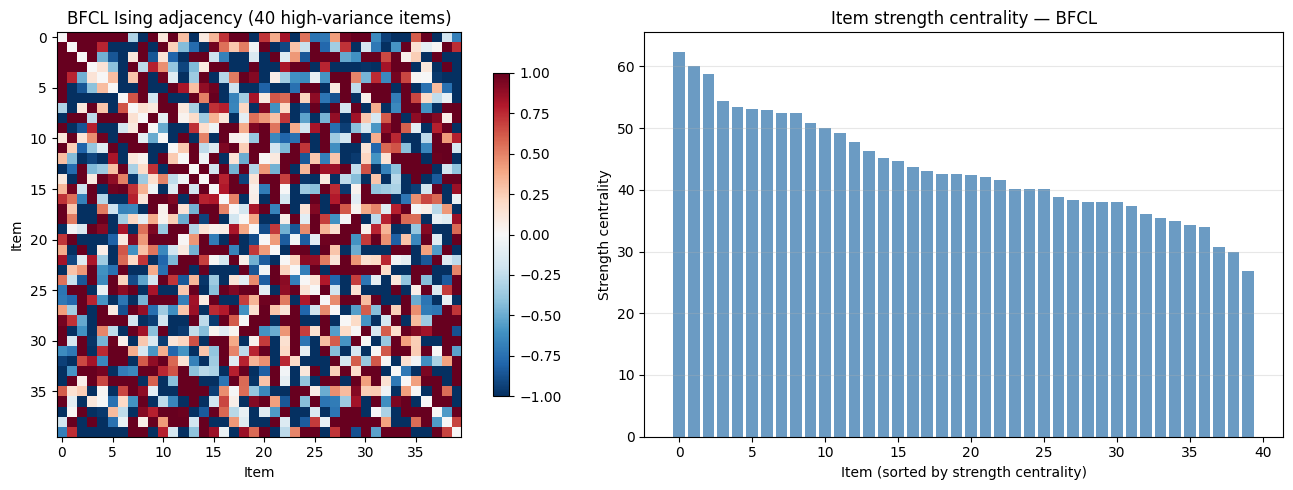

On real AI benchmarks the adjacency is noticeably sparser / noisier than the synthetic block graph in Part 1.


In [22]:
# Plot adjacency heatmap and strength centrality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(W_bfcl.numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title(f"BFCL Ising adjacency ({n_items_real} high-variance items)")
axes[0].set_xlabel("Item")
axes[0].set_ylabel("Item")
plt.colorbar(im, ax=axes[0], shrink=0.8)

centrality_bfcl = strength_centrality(W_bfcl).numpy()
order = (-centrality_bfcl).argsort()
axes[1].bar(range(len(centrality_bfcl)), centrality_bfcl[order], color="steelblue", alpha=0.8)
axes[1].set_xlabel("Item (sorted by strength centrality)")
axes[1].set_ylabel("Strength centrality")
axes[1].set_title("Item strength centrality — BFCL")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("On real AI benchmarks the adjacency is noticeably sparser / noisier than the synthetic block graph in Part 1.")


**Takeaway.** Network psychometrics is still useful on AI benchmarks — the centrality plot highlights the items that pull other items along with them — but the conditional-dependence signal is weak compared to the clean synthetic block structure. In practice expect to combine it with IRT rather than replace it.

---
## 5. Summary

| Feature | Code |
|---------|------|
| Fit Ising model | `IsingModel(n_items).fit(binary_responses)` |
| Fit GGM | `GaussianGraphicalModel(n_items, lam=0.1).fit(continuous_responses)` |
| Edge weights | `model.adjacency` — (n_items, n_items), symmetric, zero diagonal |
| Node thresholds (Ising) | `model.thresholds` |
| Precision matrix (GGM) | `model.precision`, `model.partial_correlations` |
| Conditional probabilities (Ising) | `model.conditional_probs(X)` |
| Centrality (all models) | `model.centrality("strength" / "expected_influence" / "closeness" / "betweenness")` |
| Standalone centrality | `strength_centrality(W)`, `expected_influence(W)`, `closeness_centrality(W)`, `betweenness_centrality(W)` |
| Missing data | Pass `NaN` in `response_matrix` — handled automatically |
| Sparsity control (GGM) | `lam` parameter at construction or `model.fit(..., lam=0.2)` |

### Key references
- **Epskamp & Fried (2018)**: Tutorial on regularized partial correlation networks  
- **van Borkulo et al. (2014)**: Ising model construction from binary data  
- **Friedman et al. (2008)**: GraphicalLasso for sparse precision estimation